In [17]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [18]:
import numpy as np 
from sklearn.model_selection import KFold

data = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
folds = KFold(n_splits=5, shuffle=False)

for train_idx, valid_idx in folds.split(data):
    print(f'훈련데이터: {data[train_idx]}, 검증데이터: {data[valid_idx]}')

훈련데이터: [2 3 4 5 6 7 8 9], 검증데이터: [0 1]
훈련데이터: [0 1 4 5 6 7 8 9], 검증데이터: [2 3]
훈련데이터: [0 1 2 3 6 7 8 9], 검증데이터: [4 5]
훈련데이터: [0 1 2 3 4 5 8 9], 검증데이터: [6 7]
훈련데이터: [0 1 2 3 4 5 6 7], 검증데이터: [8 9]


In [19]:
folds = KFold(n_splits=5, shuffle=True)

for train_idx, valid_idx in folds.split(data):
    print(f'훈련 데이터: {data[train_idx]}, 검증 데이터: {data[valid_idx]}')

훈련 데이터: [0 1 3 4 6 7 8 9], 검증 데이터: [2 5]
훈련 데이터: [0 1 2 3 4 5 7 8], 검증 데이터: [6 9]
훈련 데이터: [0 1 2 4 5 6 8 9], 검증 데이터: [3 7]
훈련 데이터: [1 2 3 5 6 7 8 9], 검증 데이터: [0 4]
훈련 데이터: [0 2 3 4 5 6 7 9], 검증 데이터: [1 8]


In [20]:
y = np.array(['스팸']*5 + ['일반']*45)

folds = KFold(n_splits=5, shuffle=True)

for idx, (train_idx, valid_idx) in enumerate(folds.split(y)):
    print(f'Fold {idx+1} 검증 데이터 타깃값:')
    print(y[valid_idx], '\n')

Fold 1 검증 데이터 타깃값:
['일반' '일반' '일반' '일반' '일반' '일반' '일반' '일반' '일반' '일반'] 

Fold 2 검증 데이터 타깃값:
['스팸' '스팸' '일반' '일반' '일반' '일반' '일반' '일반' '일반' '일반'] 

Fold 3 검증 데이터 타깃값:
['스팸' '일반' '일반' '일반' '일반' '일반' '일반' '일반' '일반' '일반'] 

Fold 4 검증 데이터 타깃값:
['스팸' '일반' '일반' '일반' '일반' '일반' '일반' '일반' '일반' '일반'] 

Fold 5 검증 데이터 타깃값:
['스팸' '일반' '일반' '일반' '일반' '일반' '일반' '일반' '일반' '일반'] 



In [21]:
from sklearn.model_selection import StratifiedKFold

X = np.array(range(50))
y = np.array(['스팸']*5 + ['일반']*45)

folds = StratifiedKFold(n_splits=5)

for idx, (train_idx, valid_idx) in enumerate(folds.split(X, y)):
    print(f'Fold {idx+1} 검증 데이터 값:')
    print(y[valid_idx], '\n')

Fold 1 검증 데이터 값:
['스팸' '일반' '일반' '일반' '일반' '일반' '일반' '일반' '일반' '일반'] 

Fold 2 검증 데이터 값:
['스팸' '일반' '일반' '일반' '일반' '일반' '일반' '일반' '일반' '일반'] 

Fold 3 검증 데이터 값:
['스팸' '일반' '일반' '일반' '일반' '일반' '일반' '일반' '일반' '일반'] 

Fold 4 검증 데이터 값:
['스팸' '일반' '일반' '일반' '일반' '일반' '일반' '일반' '일반' '일반'] 

Fold 5 검증 데이터 값:
['스팸' '일반' '일반' '일반' '일반' '일반' '일반' '일반' '일반' '일반'] 



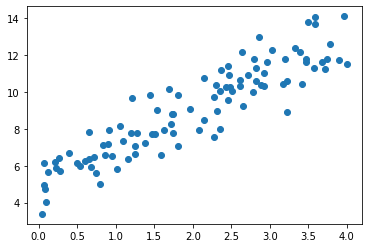

In [22]:
import numpy as np 
import matplotlib.pyplot as plt

np.random.seed(0)

w0 = 5
w1 = 2
noise = np.random.randn(100, 1)

x = 4 * np.random.rand(100, 1)
y = w1*x + w0 + noise

plt.scatter(x, y);

In [23]:
from sklearn.linear_model import LinearRegression

linear_reg_model = LinearRegression()
linear_reg_model.fit(x, y)

print('y절편(w0):', linear_reg_model.intercept_)
print('회귀계수(w1):', linear_reg_model.coef_)

y절편(w0): [5.09772262]
회귀계수(w1): [[1.9808382]]


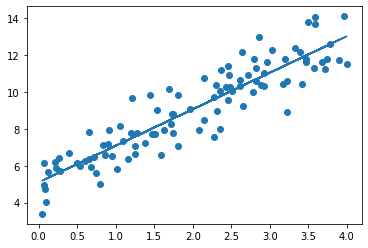

In [24]:
y_pred = linear_reg_model.predict(x)

plt.scatter(x, y)
plt.plot(x, y_pred);

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

cancer_data = load_breast_cancer()

In [26]:
X_train, X_test, y_train, y_test = train_test_split(cancer_data['data'],
                                                   cancer_data['target'],
                                                   stratify=cancer_data['target'],
                                                   test_size=0.4,
                                                   random_state=42)

decisiontree = DecisionTreeClassifier(random_state=42)
decisiontree.fit(X_train, y_train)

accuracy = decisiontree.score(X_test, y_test)

print(f'결정 트리 정확도: {accuracy:.3f}')

결정 트리 정확도: 0.930


In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

cancer_data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(cancer_data['data'],
                                                   cancer_data['target'],
                                                   stratify=cancer_data['target'],
                                                   test_size=0.4,
                                                   random_state=42)

randomforest = RandomForestClassifier(random_state=42)
randomforest.fit(X_train, y_train)

accuracy = randomforest.score(X_test, y_test)

print(f'랜덤 포레스트 정확도: {accuracy:.3f}')

랜덤 포레스트 정확도: 0.939


In [28]:
param_bounds = {'x': (-1, 5),
               'y': (0,4)}

In [29]:
def eval_function(x,y):
    return -x ** 2 -(y-2) ** 2 +10

In [30]:
from bayes_opt import BayesianOptimization

optimizer = BayesianOptimization(f=eval_function,
                                pbounds=param_bounds,
                                random_state=0)

In [31]:
optimizer.maximize(init_points=2, n_iter=10)

|   iter    |  target   |     x     |     y     |
-------------------------------------------------
|  1        |  4.002    |  2.293    |  2.861    |
|  2        |  3.121    |  2.617    |  2.18     |
|  3        |  3.832    |  2.327    |  2.869    |
|  4        |  4.596    |  2.171    |  2.832    |
|  5        | -6.227    |  3.989    |  2.559    |
|  6        |  9.467    |  0.3522   |  1.361    |
|  7        |  7.39     | -1.0      |  3.269    |
|  8        |  5.0      | -1.0      |  0.0      |
|  9        |  3.841    |  1.469    |  0.0      |
|  10       |  8.966    | -1.0      |  1.817    |
|  11       |  9.737    |  0.1806   |  2.48     |
|  12       |  5.785    |  0.4638   |  4.0      |


In [32]:
# 평가점수가 최대일 때 타깃 , x, y값 출력
optimizer.max

{'target': 9.73708754050397,
 'params': {'x': 0.18063747442587866, 'y': 2.4798776535004214}}